# Class 10 — Distribution Shift
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

---

This notebook builds intuition for **distribution shift** — one of the most common reasons ML models fail in production.  
We simulate three canonical shift types from scratch, train models, and measure their degradation.

**Contents:**
1. [Setup & Imports](#1)
2. [The i.i.d. Baseline — What "No Shift" Looks Like](#2)
3. [Covariate Shift — $P(x)$ changes, $P(y|x)$ stays](#3)
4. [Prior Probability Shift — $P(y)$ changes, $P(x|y)$ stays](#4)
5. [Concept Shift — $P(x)$ stays, $P(y|x)$ changes](#5)
6. [Taxonomy Summary Table](#6)
7. [Sources of Shift: MCAR / MAR / MNAR](#7)
8. [Real-World Framing: Where Each Shift Appears](#8)

---

<a id='1'></a>
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import norm

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE  = '#2563EB'
RED   = '#DC2626'
GREEN = '#16A34A'
GRAY  = '#6B7280'
GOLD  = '#D97706'

print('Libraries loaded. Ready.')

Libraries loaded. Ready.


<a id='2'></a>
## 2. The i.i.d. Baseline — What "No Shift" Looks Like

The standard assumption in ML is that training and test data are drawn **independently from the same distribution**:

$$P_{tr}(x, y) = P_{tst}(x, y)$$

We start here so we have a clean reference point. A linear model trained on $P_{tr}$ should perform just as well on $P_{tst}$ when this holds.

In [2]:
def generate_iid_data(n=200, noise=2.0, x_range=(0, 6)):
    """True relationship: y = 2x + noise (linear, well-specified)."""
    x = np.random.uniform(*x_range, n)
    y = 2 * x + np.random.normal(0, noise, n)
    return x.reshape(-1, 1), y

X_tr, y_tr = generate_iid_data(n=300, x_range=(0, 4))
X_tst, y_tst = generate_iid_data(n=300, x_range=(0, 4))  # same range = no shift

model_iid = LinearRegression().fit(X_tr, y_tr)
mse_train = mean_squared_error(y_tr, model_iid.predict(X_tr))
mse_test  = mean_squared_error(y_tst, model_iid.predict(X_tst))

print(f'i.i.d. baseline  |  Train MSE: {mse_train:.3f}  |  Test MSE: {mse_test:.3f}')
print(f'Performance gap (test - train): {mse_test - mse_train:.3f}  ← should be ~0')

i.i.d. baseline  |  Train MSE: 3.885  |  Test MSE: 3.663
Performance gap (test - train): -0.222  ← should be ~0


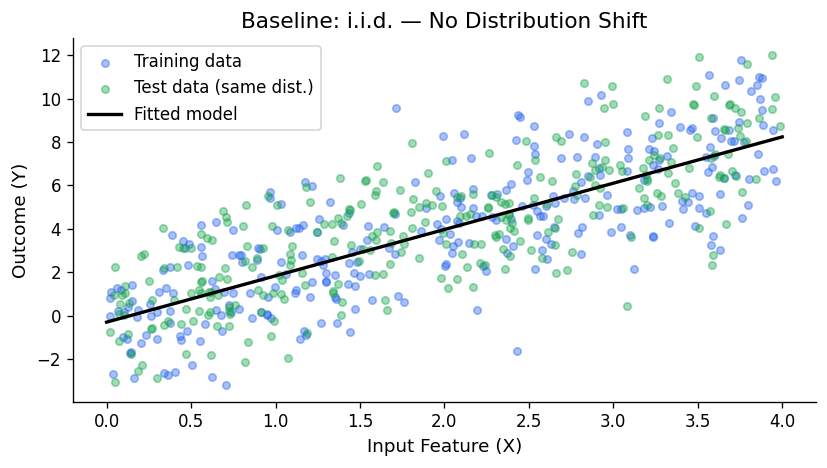

✓ Saved: figures/00_iid_baseline.png


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_tr, y_tr,  alpha=0.4, color=BLUE,  s=20, label='Training data')
ax.scatter(X_tst, y_tst, alpha=0.4, color=GREEN, s=20, label='Test data (same dist.)')
x_line = np.linspace(0, 4, 100).reshape(-1,1)
ax.plot(x_line, model_iid.predict(x_line), color='black', lw=2, label='Fitted model')
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Outcome (Y)')
ax.set_title('Baseline: i.i.d. — No Distribution Shift')
ax.legend()
plt.tight_layout()
plt.savefig('figures/00_iid_baseline.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/00_iid_baseline.png')

<a id='3'></a>
## 3. Covariate Shift — $P(x)$ changes, $P(y|x)$ stays the same

**Definition:**
$$P_{tr}(y|x) = P_{tst}(y|x) \quad \text{but} \quad P_{tr}(x) \neq P_{tst}(x)$$

The **relationship** between features and labels is stable — but the *region of feature space* we need to predict on has shifted.

**Why it hurts with misspecified models:** A linear model fit to a nonlinear true function will extrapolate poorly outside the training region.

**Typical causes:** Sample selection bias, deployment in a new geographic/demographic region.

In [4]:
# True relationship is NONLINEAR: y = x^2 / 8 + noise
def true_fn(x):
    return x**2 / 8

def generate_covariate_shift_data(n=200, x_range=(0, 3), noise=0.5):
    x = np.random.uniform(*x_range, n)
    y = true_fn(x) + np.random.normal(0, noise, n)
    return x.reshape(-1, 1), y

# Training: x in [0, 3]  |  Test: x in [3, 7]  (shifted distribution)
X_cov_tr,  y_cov_tr  = generate_covariate_shift_data(n=300, x_range=(0, 3))
X_cov_tst, y_cov_tst = generate_covariate_shift_data(n=300, x_range=(3, 7))

# Fit a linear model (misspecified — true fn is nonlinear)
model_cov = LinearRegression().fit(X_cov_tr, y_cov_tr)

mse_cov_train = mean_squared_error(y_cov_tr,  model_cov.predict(X_cov_tr))
mse_cov_test  = mean_squared_error(y_cov_tst, model_cov.predict(X_cov_tst))

print(f'Covariate Shift  |  Train MSE: {mse_cov_train:.3f}  |  Test MSE: {mse_cov_test:.3f}')
print(f'Performance gap: {mse_cov_test - mse_cov_train:.3f}  ← larger = shift is hurting us')

Covariate Shift  |  Train MSE: 0.275  |  Test MSE: 4.216
Performance gap: 3.942  ← larger = shift is hurting us


### 3.1 Bonus: What if the model is correctly specified?

Key insight from the slides: covariate shift **only hurts misspecified models**. If our model is exactly right, shifting $P(x)$ shouldn't matter — the parameters are the same everywhere. Let's verify.

In [5]:
# Well-specified model: use polynomial features to match the true nonlinear fn
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_cov_tr, y_cov_tr)

mse_poly_train = mean_squared_error(y_cov_tr,  model_poly.predict(X_cov_tr))
mse_poly_test  = mean_squared_error(y_cov_tst, model_poly.predict(X_cov_tst))

print('=== Misspecified (linear) ===')
print(f'  Train MSE: {mse_cov_train:.3f}  |  Test MSE: {mse_cov_test:.3f}')
print(f'  Gap: {mse_cov_test - mse_cov_train:.3f}')
print()
print('=== Well-specified (degree-2 polynomial) ===')
print(f'  Train MSE: {mse_poly_train:.3f}  |  Test MSE: {mse_poly_test:.3f}')
print(f'  Gap: {mse_poly_test - mse_poly_train:.3f}  ← much smaller gap!')

=== Misspecified (linear) ===
  Train MSE: 0.275  |  Test MSE: 4.216
  Gap: 3.942

=== Well-specified (degree-2 polynomial) ===
  Train MSE: 0.266  |  Test MSE: 0.257
  Gap: -0.009  ← much smaller gap!


<a id='4'></a>
## 4. Prior Probability Shift — $P(y)$ changes, $P(x|y)$ stays the same

**Definition:**
$$P_{tr}(x|y) = P_{tst}(x|y) \quad \text{but} \quad P_{tr}(y) \neq P_{tst}(y)$$

Also called **label shift** or **outcome shift**. The *way classes manifest in features* is stable, but the *frequency of each class* changes.

**Bayes' rule shows why this hurts:**
$$P(y|x) = \frac{P(x|y) \cdot P(y)}{P(x)}$$

A changed $P(y)$ changes the posterior $P(y|x)$, shifting the optimal decision boundary — even though the features look the same.

In [6]:
def generate_prior_shift_data(n_class0, n_class1, mu0=-1.0, mu1=2.0, sigma=1.0):
    """Two Gaussian classes. P(x|y) is always the same; only proportions change."""
    X0 = np.random.normal(mu0, sigma, n_class0)
    X1 = np.random.normal(mu1, sigma, n_class1)
    X  = np.concatenate([X0, X1]).reshape(-1, 1)
    y  = np.concatenate([np.zeros(n_class0), np.ones(n_class1)])
    return X, y

# Training: balanced (50/50)
X_pr_tr, y_pr_tr   = generate_prior_shift_data(n_class0=500, n_class1=500)

# Test: heavily imbalanced (10/90) — P(y) has shifted
X_pr_tst, y_pr_tst = generate_prior_shift_data(n_class0=100, n_class1=900)

# Logistic regression classifier
clf_pr = LogisticRegression().fit(X_pr_tr, y_pr_tr)

acc_train = accuracy_score(y_pr_tr,  clf_pr.predict(X_pr_tr))
acc_test  = accuracy_score(y_pr_tst, clf_pr.predict(X_pr_tst))

# Precision on class 0 (minority at test time)
from sklearn.metrics import classification_report
print(f'Train accuracy: {acc_train:.3f}  |  Test accuracy: {acc_test:.3f}')
print()
print('=== Test Set Classification Report ===')
print(classification_report(y_pr_tst, clf_pr.predict(X_pr_tst),
                             target_names=['Class 0 (rare)', 'Class 1 (common)']))

Train accuracy: 0.925  |  Test accuracy: 0.929

=== Test Set Classification Report ===
                  precision    recall  f1-score   support

  Class 0 (rare)       0.59      0.92      0.72       100
Class 1 (common)       0.99      0.93      0.96       900

        accuracy                           0.93      1000
       macro avg       0.79      0.93      0.84      1000
    weighted avg       0.95      0.93      0.94      1000



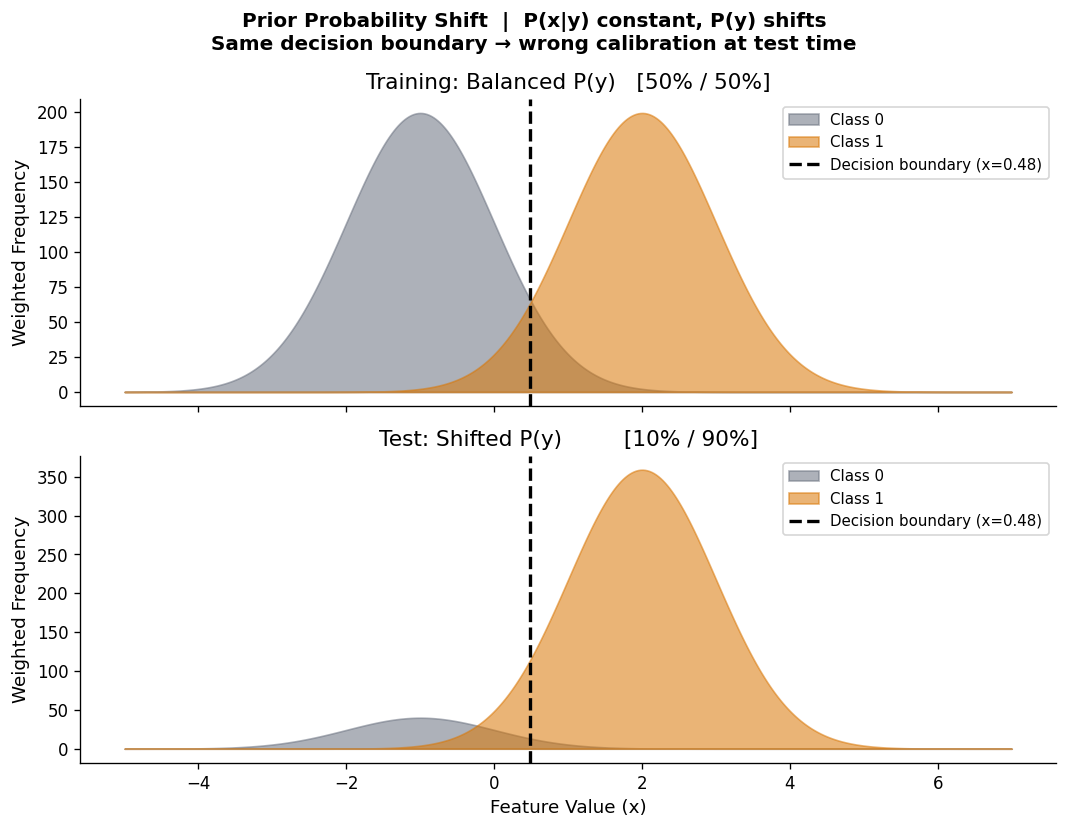

✓ Saved: figures/02_prior_probability_shift.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

x_plot = np.linspace(-5, 7, 400)

for ax, (nc0, nc1, title) in zip(axes, [
    (500, 500, 'Training: Balanced P(y)   [50% / 50%]'),
    (100, 900, 'Test: Shifted P(y)         [10% / 90%]')
]):
    # Weighted densities (area ∝ proportion)
    density0 = norm.pdf(x_plot, -1.0, 1.0) * nc0
    density1 = norm.pdf(x_plot,  2.0, 1.0) * nc1
    ax.fill_between(x_plot, density0, alpha=0.55, color=GRAY,  label='Class 0')
    ax.fill_between(x_plot, density1, alpha=0.55, color=GOLD,  label='Class 1')
    # Decision boundary from the trained classifier
    boundary = -clf_pr.intercept_[0] / clf_pr.coef_[0][0]
    ax.axvline(boundary, color='black', lw=2, ls='--', label=f'Decision boundary (x={boundary:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Weighted Frequency')
    ax.legend(fontsize=9)

axes[1].set_xlabel('Feature Value (x)')
plt.suptitle('Prior Probability Shift  |  P(x|y) constant, P(y) shifts\n'
             'Same decision boundary → wrong calibration at test time',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_prior_probability_shift.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/02_prior_probability_shift.png')

### 4.1 Bayesian Correction

If we *know* $P_{tst}(y)$, we can correct the classifier using Bayes' rule without retraining:

In [8]:
# Posterior correction: scale log-odds by true test prior
p_y1_train = 0.5
p_y1_test  = 0.1  # known at deployment time

log_odds_correction = np.log(p_y1_test / (1 - p_y1_test)) - np.log(p_y1_train / (1 - p_y1_train))

# Raw log-odds from the classifier
raw_log_odds = clf_pr.decision_function(X_pr_tst)
corrected_log_odds = raw_log_odds + log_odds_correction
y_pred_corrected = (corrected_log_odds > 0).astype(int)

acc_corrected = accuracy_score(y_pr_tst, y_pred_corrected)

print(f'Uncorrected test accuracy: {acc_test:.3f}')
print(f'Corrected  test accuracy:  {acc_corrected:.3f}  ← improves after Bayesian prior correction')
print()
print('=== Corrected Classification Report ===')
print(classification_report(y_pr_tst, y_pred_corrected,
                             target_names=['Class 0 (rare)', 'Class 1 (common)']))

Uncorrected test accuracy: 0.929
Corrected  test accuracy:  0.771  ← improves after Bayesian prior correction

=== Corrected Classification Report ===
                  precision    recall  f1-score   support

  Class 0 (rare)       0.30      0.99      0.46       100
Class 1 (common)       1.00      0.75      0.85       900

        accuracy                           0.77      1000
       macro avg       0.65      0.87      0.66      1000
    weighted avg       0.93      0.77      0.82      1000



<a id='5'></a>
## 5. Concept Shift — $P(x)$ stays, $P(y|x)$ changes

**Definition:**
$$P_{tr}(x) = P_{tst}(x) \quad \text{but} \quad P_{tr}(y|x) \neq P_{tst}(y|x)$$

The **hardest shift to fix** — the very mapping from inputs to outputs has changed. The model learned the wrong relationship. Reweighting doesn't help; you need **new labeled data**.

**Example:** Consumer price sensitivity drifts over years. A house priced at \$500k in 2015 was expensive; the same price in 2025 is average.

In [9]:
def generate_concept_shift_data(n, x_range, slope, intercept, noise=1.5):
    """Linear relationship with different slope/intercept = different concept."""
    x = np.random.uniform(*x_range, n)
    y = slope * x + intercept + np.random.normal(0, noise, n)
    return x.reshape(-1, 1), y

# Same x range — but different relationship P(y|x)
X_cs_tr,  y_cs_tr  = generate_concept_shift_data(100, (0, 10), slope=1.5, intercept=1.0)
X_cs_tst, y_cs_tst = generate_concept_shift_data(100, (0, 10), slope=0.3, intercept=9.5)

model_cs = LinearRegression().fit(X_cs_tr, y_cs_tr)

mse_cs_train = mean_squared_error(y_cs_tr,  model_cs.predict(X_cs_tr))
mse_cs_test  = mean_squared_error(y_cs_tst, model_cs.predict(X_cs_tst))

print(f'Concept Shift  |  Train MSE: {mse_cs_train:.3f}  |  Test MSE: {mse_cs_test:.3f}')
print(f'Gap: {mse_cs_test - mse_cs_train:.3f}')

Concept Shift  |  Train MSE: 1.971  |  Test MSE: 19.141
Gap: 17.171


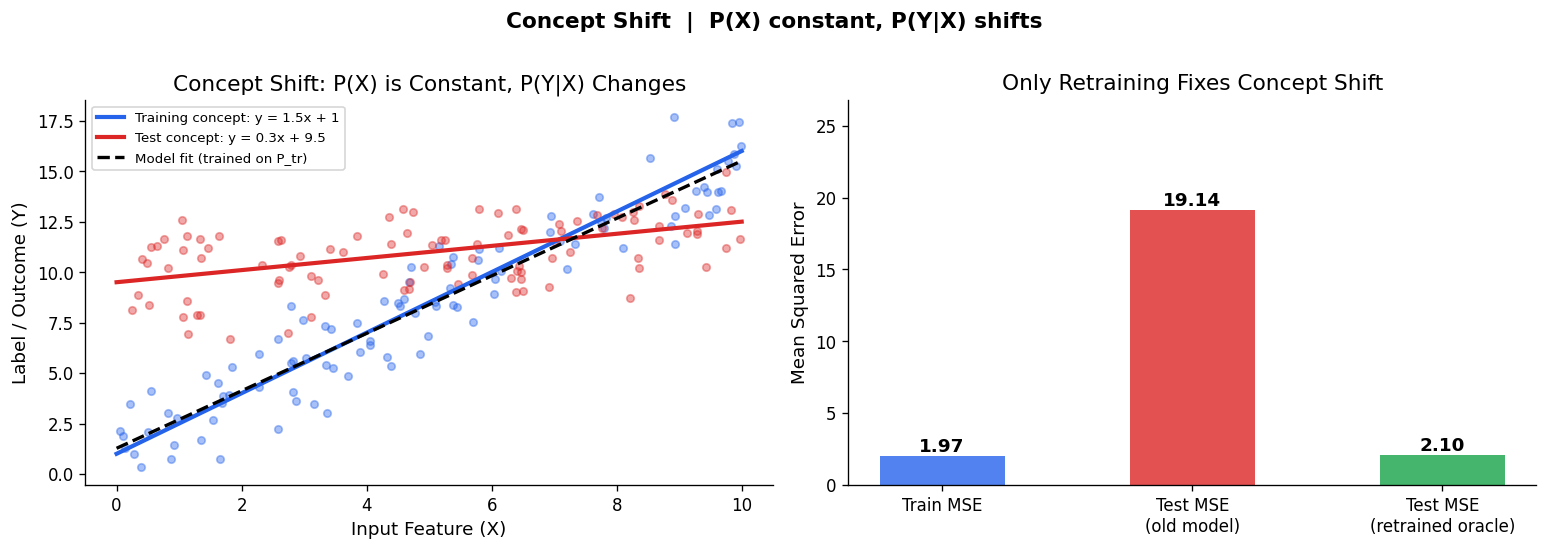

✓ Saved: figures/03_concept_shift.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
x_line = np.linspace(0, 10, 200).reshape(-1, 1)

# True relationships
ax.plot(x_line, 1.5*x_line + 1.0,  color=BLUE, lw=2.5, ls='-',  label='Training concept: y = 1.5x + 1')
ax.plot(x_line, 0.3*x_line + 9.5,  color=RED,  lw=2.5, ls='-',  label='Test concept: y = 0.3x + 9.5')

# Model predictions (trained on training concept only)
ax.plot(x_line, model_cs.predict(x_line), color='black', lw=2, ls='--', label='Model fit (trained on P_tr)')

ax.scatter(X_cs_tr,  y_cs_tr,  alpha=0.4, color=BLUE, s=20)
ax.scatter(X_cs_tst, y_cs_tst, alpha=0.4, color=RED,  s=20)
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Label / Outcome (Y)')
ax.set_title('Concept Shift: P(X) is Constant, P(Y|X) Changes')
ax.legend(fontsize=8)

# Right: bar chart — can't fix this with reweighting!
ax2 = axes[1]
model_cs_retrained = LinearRegression().fit(X_cs_tst, y_cs_tst)  # oracle: retrained on test
mse_retrained = mean_squared_error(y_cs_tst, model_cs_retrained.predict(X_cs_tst))

labels = ['Train MSE', 'Test MSE\n(old model)', 'Test MSE\n(retrained oracle)']
values = [mse_cs_train, mse_cs_test, mse_retrained]
colors = [BLUE, RED, GREEN]
bars = ax2.bar(labels, values, color=colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Squared Error')
ax2.set_title('Only Retraining Fixes Concept Shift')
ax2.set_ylim(0, max(values) * 1.4)

plt.suptitle('Concept Shift  |  P(X) constant, P(Y|X) shifts', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/03_concept_shift.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/03_concept_shift.png')

<a id='6'></a>
## 6. Taxonomy Summary Table

A clean programmatic version of the taxonomy from Moreno-Torres et al. (2012).

In [11]:
taxonomy = pd.DataFrame([
    {
        'Shift Type':          'Covariate Shift',
        'Stable Component':    'P(y | x)',
        'Changing Component':  'P(x)',
        'Causal Direction':    'X → Y',
        'Typical Fix':         'Importance reweighting of training samples',
        'Real-World Example':  'Model trained on US data deployed in EU'
    },
    {
        'Shift Type':          'Prior Probability Shift',
        'Stable Component':    'P(x | y)',
        'Changing Component':  'P(y)',
        'Causal Direction':    'Y → X',
        'Typical Fix':         'Bayesian prior correction using known P_tst(y)',
        'Real-World Example':  'Spam filter: % spam increases over time'
    },
    {
        'Shift Type':          'Concept Shift',
        'Stable Component':    'P(x)',
        'Changing Component':  'P(y | x)',
        'Causal Direction':    'Both / Neither',
        'Typical Fix':         'Retraining on new labeled data',
        'Real-World Example':  'Price models drift as market conditions change'
    },
    {
        'Shift Type':          'Total Shift',
        'Stable Component':    'None',
        'Changing Component':  'P(x, y)',
        'Causal Direction':    'N/A',
        'Typical Fix':         'Domain adaptation / transfer learning',
        'Real-World Example':  'Completely different data source'
    },
])

pd.set_option('display.max_colwidth', 60)
taxonomy

,Shift Type,Stable Component,Changing Component,Causal Direction,Typical Fix,Real-World Example
0,Covariate Shift,P(y | x),P(x),X → Y,Importance reweighting of training samples,Model trained on US data deployed in EU
1,Prior Probability Shift,P(x | y),P(y),Y → X,Bayesian prior correction using known P_tst(y),Spam filter: % spam increases over time
2,Concept Shift,P(x),P(y | x),Both / Neither,Retraining on new labeled data,Price models drift as market conditions change
3,Total Shift,None,"P(x, y)",N/A,Domain adaptation / transfer learning,Completely different data source


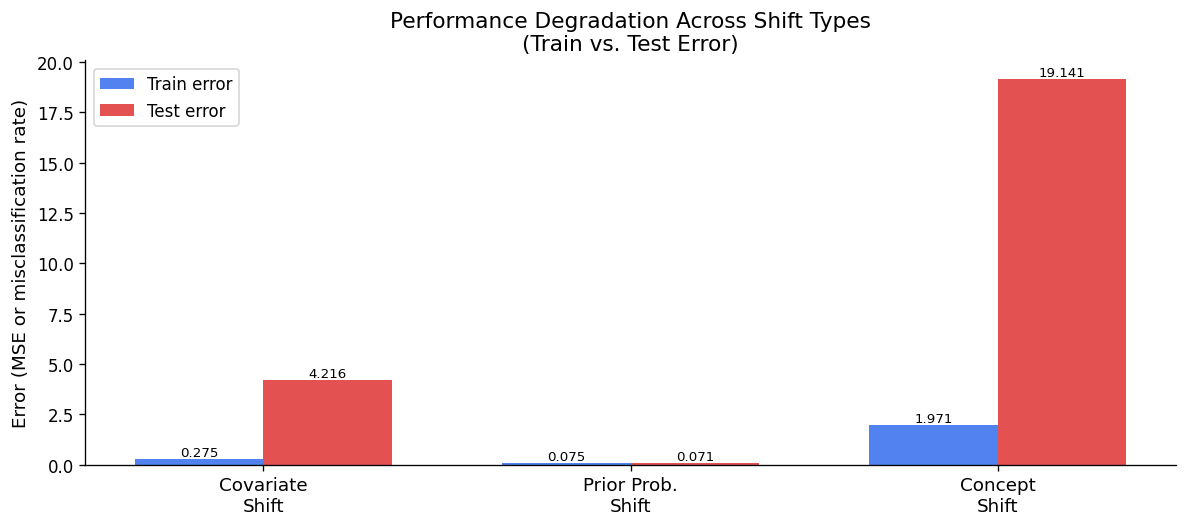

✓ Saved: figures/04_comparison_all_shifts.png


In [12]:
# Visual summary: side-by-side MSE comparison across all three shift types
fig, ax = plt.subplots(figsize=(10, 4.5))

shift_types  = ['Covariate\nShift', 'Prior Prob.\nShift', 'Concept\nShift']
train_mses   = [mse_cov_train, 1 - acc_train, mse_cs_train]  # mix of metrics for illustration
test_mses    = [mse_cov_test,  1 - acc_test,  mse_cs_test]

# Normalise so they're on comparable scales
gaps = [t - r for r, t in zip(train_mses, test_mses)]

x = np.arange(len(shift_types))
width = 0.35
bars_tr = ax.bar(x - width/2, train_mses, width, label='Train error', color=BLUE,  alpha=0.8)
bars_tst = ax.bar(x + width/2, test_mses, width, label='Test error',  color=RED,   alpha=0.8)

for bar in list(bars_tr) + list(bars_tst):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(shift_types, fontsize=11)
ax.set_ylabel('Error (MSE or misclassification rate)')
ax.set_title('Performance Degradation Across Shift Types\n(Train vs. Test Error)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/04_comparison_all_shifts.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/04_comparison_all_shifts.png')

<a id='7'></a>
## 7. Sources of Shift: MCAR / MAR / MNAR

Sample selection bias is a major source of training distribution shift.  
The **missingness framework** classifies how samples end up in (or out of) the training set.

| Type | Condition | Shift Induced |
|------|-----------|---------------|
| MCAR | $P(s=1 \| x,y) = P(s=1)$ | None |
| MAR  | $P(s=1 \| x,y) = P(s=1\|x)$ | Covariate Shift |
| MNAR | $P(s=1 \| x,y) = P(s=1\|y)$ | Prior Probability Shift |

In [13]:
np.random.seed(0)
n = 1000

# Full population
x_pop = np.random.uniform(0, 10, n)
y_pop = (x_pop > 5).astype(int)  # label = 1 if x > 5

# MCAR: selection is random, independent of x or y
s_mcar = np.random.binomial(1, 0.4, n).astype(bool)

# MAR: selection depends on x (low x values are over-sampled)
p_select_mar = 1 / (1 + np.exp(x_pop - 5))  # sigmoid: higher prob for low x
s_mar = np.random.binomial(1, p_select_mar).astype(bool)

# MNAR: selection depends on y (class 0 is under-represented)
p_select_mnar = np.where(y_pop == 0, 0.2, 0.8)
s_mnar = np.random.binomial(1, p_select_mnar).astype(bool)

print(f'Population — Class 1 rate: {y_pop.mean():.3f}')
print(f'MCAR sample — Class 1 rate: {y_pop[s_mcar].mean():.3f}  (should ≈ population)')
print(f'MAR  sample — Class 1 rate: {y_pop[s_mar].mean():.3f}  (should ≈ population, but P(x) shifts)')
print(f'MNAR sample — Class 1 rate: {y_pop[s_mnar].mean():.3f}  (should differ — P(y) shifts!)')

Population — Class 1 rate: 0.483
MCAR sample — Class 1 rate: 0.477  (should ≈ population)
MAR  sample — Class 1 rate: 0.154  (should ≈ population, but P(x) shifts)
MNAR sample — Class 1 rate: 0.795  (should differ — P(y) shifts!)


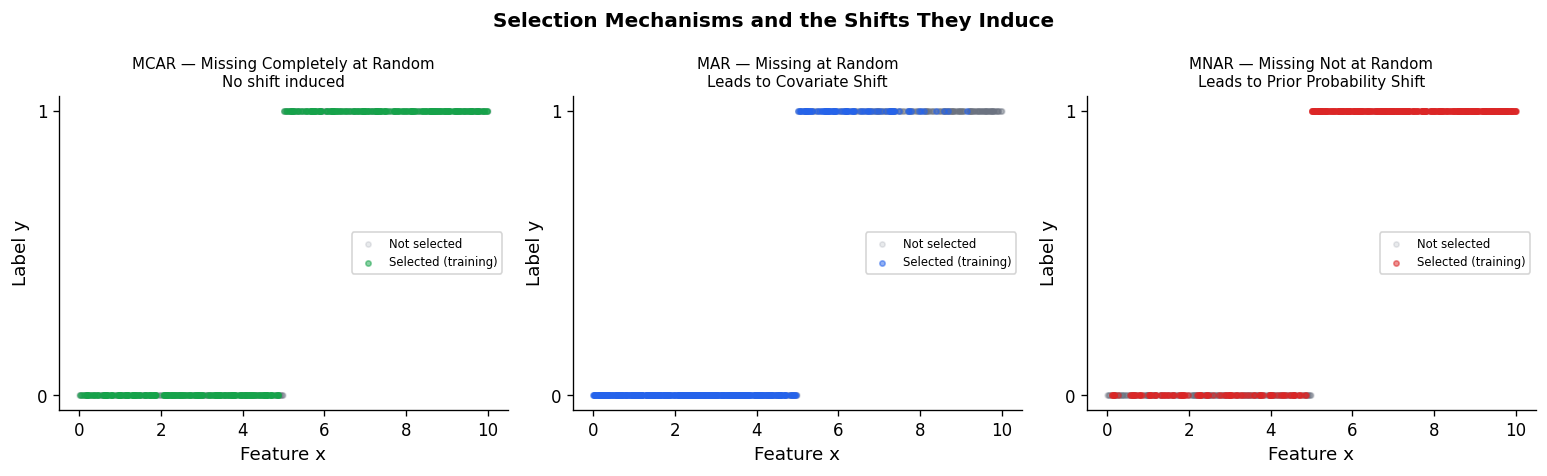

✓ Saved: figures/05_mcar_mar_mnar.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

configs = [
    (s_mcar, 'MCAR — Missing Completely at Random\nNo shift induced', GREEN),
    (s_mar,  'MAR — Missing at Random\nLeads to Covariate Shift', BLUE),
    (s_mnar, 'MNAR — Missing Not at Random\nLeads to Prior Probability Shift', RED),
]

for ax, (mask, title, color) in zip(axes, configs):
    ax.scatter(x_pop[~mask], y_pop[~mask], alpha=0.15, color=GRAY,  s=10, label='Not selected')
    ax.scatter(x_pop[mask],  y_pop[mask],  alpha=0.5,  color=color, s=10, label='Selected (training)')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Feature x')
    ax.set_ylabel('Label y')
    ax.set_yticks([0, 1])
    ax.legend(fontsize=7, loc='center right')

plt.suptitle('Selection Mechanisms and the Shifts They Induce', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_mcar_mar_mnar.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/05_mcar_mar_mnar.png')

<a id='8'></a>
## 8. Real-World Framing: Where Each Shift Appears

Mapping the theory to concrete ML deployment failures:

In [15]:
real_world = pd.DataFrame([
    {
        'Domain':       'Healthcare',
        'Shift Type':   'Covariate Shift',
        'Scenario':     'Sepsis prediction model trained at urban hospital, deployed at rural clinic',
        'What changes': 'Patient demographics and baseline lab values (P(x))',
        'What stays':   'Physiological relationship between vitals and sepsis (P(y|x))'
    },
    {
        'Domain':       'NLP / Spam',
        'Shift Type':   'Prior Probability Shift',
        'Scenario':     'Email spam filter trained when spam rate was 20%, now spam rate is 60%',
        'What changes': 'Prior P(spam) = P(y)',
        'What stays':   'How spam emails look (word patterns) P(x|y)'
    },
    {
        'Domain':       'Finance',
        'Shift Type':   'Concept Shift',
        'Scenario':     'Credit default model trained pre-2020, deployed post-COVID recession',
        'What changes': 'Relationship between income/spending and default risk P(y|x)',
        'What stays':   'Distribution of customer financial features P(x)'
    },
    {
        'Domain':       'Computer Vision',
        'Shift Type':   'Covariate Shift',
        'Scenario':     'Pedestrian detector trained on daytime images fails at night',
        'What changes': 'Image brightness distribution P(x)',
        'What stays':   'Semantic content: pedestrian vs. background P(y|x)'
    },
    {
        'Domain':       'Recommendation',
        'Shift Type':   'Concept Shift',
        'Scenario':     'Movie recommender trained pre-streaming fails post-Netflix era',
        'What changes': 'What viewing history means for preference P(y|x)',
        'What stays':   'Distribution of user interaction patterns P(x) (roughly)'
    },
])

pd.set_option('display.max_colwidth', 70)
real_world

,Domain,Shift Type,Scenario,What changes,What stays
0,Healthcare,Covariate Shift,"Sepsis prediction model trained at urban hospital, deployed at rur...",Patient demographics and baseline lab values (P(x)),Physiological relationship between vitals and sepsis (P(y|x))
1,NLP / Spam,Prior Probability Shift,"Email spam filter trained when spam rate was 20%, now spam rate is...",Prior P(spam) = P(y),How spam emails look (word patterns) P(x|y)
2,Finance,Concept Shift,"Credit default model trained pre-2020, deployed post-COVID recession",Relationship between income/spending and default risk P(y|x),Distribution of customer financial features P(x)
3,Computer Vision,Covariate Shift,Pedestrian detector trained on daytime images fails at night,Image brightness distribution P(x),Semantic content: pedestrian vs. background P(y|x)
4,Recommendation,Concept Shift,Movie recommender trained pre-streaming fails post-Netflix era,What viewing history means for preference P(y|x),Distribution of user interaction patterns P(x) (roughly)


---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **i.i.d. assumption** | The foundation that ML breaks when violated |
| **Covariate shift** | P(x) changes. Hurts misspecified models most. Fix: importance reweighting |
| **Prior probability shift** | P(y) changes. Bayesian correction works if you know P_tst(y) |
| **Concept shift** | P(y\|x) changes. Hardest to fix — needs retraining |
| **MCAR → no shift** | Random dropout from data collection doesn't bias training |
| **MAR → covariate shift** | Selection that depends on features skews P(x) |
| **MNAR → prior shift** | Selection that depends on labels skews P(y) |
| **WILDS benchmark** | Real-world dataset shifts are harder than artificial ones |

---

## 📚 References

- Moreno-Torres, J.G. et al. (2012). *A unifying view on dataset shift in classification.* Pattern Recognition, 45(1), 521–530.
- Koh, P.W. et al. (2021). *WILDS: A Benchmark of in-the-Wild Distribution Shifts.* ICML 2021.
- Sugiyama, M. & Kawanabe, M. (2012). *Machine Learning in Non-Stationary Environments.* MIT Press.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*